In [1]:
from typing import Literal, TypedDict

from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph


In [2]:
@tool
def science_fact_tool(topic: str) -> str:
    """Return a simple science fact for a children's audio script."""
    facts = {
        "the moon": (
            "The moon does not make its own light. It reflects light from the sun, "
            "and it moves around Earth."
        ),
        "rainbows": (
            "A rainbow appears when sunlight passes through tiny drops of water and "
            "the light spreads into many colors."
        ),
        "dinosaurs": (
            "Dinosaurs lived a long time ago, and scientists learn about them by "
            "studying fossils in rocks."
        ),
    }
    return facts.get(
        topic.lower(),
        f"{topic.title()} is a science topic we can explain with one simple fact and repeated English phrases.",
    )


@tool
def vocabulary_tool(topic: str) -> list[str]:
    """Return simple English vocabulary words related to the topic."""
    words = {
        "the moon": ["moon", "light", "night"],
        "rainbows": ["rainbow", "color", "rain"],
        "dinosaurs": ["dinosaur", "bone", "fossil"],
    }
    return words.get(topic.lower(), ["science", "learn", "fun"])


@tool
def parent_tip_tool(age_group: str) -> str:
    """Return a parent coaching tip matched to the child's age group."""
    tips = {
        "4-5": "Pause after each short line and let the child repeat one keyword.",
        "6-8": "Ask the child to repeat the key phrase and explain one idea in their own words.",
        "9-10": "Ask one follow-up why-question after the episode to deepen understanding.",
    }
    return tips.get(age_group, "Repeat one key phrase together after listening.")


class EpisodeState(TypedDict, total=False):
    age_group: str
    topic: str
    duration_minutes: int
    tone: str
    review_status: Literal["approve", "revise"]
    revision_request: str
    plan: str
    science_fact: str
    target_words: list[str]
    parent_tip: str
    script: str
    parent_summary: str


In [4]:
def plan_episode(state: EpisodeState) -> EpisodeState:
    plan = (
        f"- Audience: {state['age_group']}\n"
        f"- Topic: {state['topic']}\n"
        f"- Length: about {state['duration_minutes']} minutes\n"
        f"- Tone: {state['tone']}\n"
        "- Characters: Curious Kid Leo, Dr. Spark\n"
        "- Goal: teach one science idea with easy English and repetition"
    )
    return {"plan": plan}


def research_topic(state: EpisodeState) -> EpisodeState:
    science_fact = science_fact_tool.invoke({"topic": state["topic"]})
    target_words = vocabulary_tool.invoke({"topic": state["topic"]})
    parent_tip = parent_tip_tool.invoke({"age_group": state["age_group"]})
    return {
        "science_fact": science_fact,
        "target_words": target_words,
        "parent_tip": parent_tip,
    }


def write_script(state: EpisodeState) -> EpisodeState:
    topic = state["topic"]
    fact = state["science_fact"]
    words = ", ".join(state["target_words"])
    script = f"""
[Leo] Dr. Spark, I want to learn about {topic}!

[Dr. Spark] Great question, Leo. Here is a simple idea: {fact}

[Leo] Wow! Can you say it again?

[Dr. Spark] Sure. Learning about {topic} is fun. Look up! Ask why! Science is fun!

[Leo] Look up! Ask why! Science is fun!

[Dr. Spark] Today's words are: {words}.
""".strip()
    return {"script": script}


def review_script(state: EpisodeState) -> EpisodeState:
    return {"review_status": state.get("review_status", "approve")}


def route_after_review(state: EpisodeState) -> str:
    return state["review_status"]


def revise_script(state: EpisodeState) -> EpisodeState:
    revision_request = state.get(
        "revision_request",
        "Make the explanation even simpler for young children.",
    )
    revised_script = (
        f"{state['script']}\n\n"
        f"[Dr. Spark] Parent request noted: {revision_request}\n"
        "[Dr. Spark] Let me say it in an even easier way. Science can be simple and fun!"
    )
    return {"script": revised_script, "review_status": "approve"}


def summarize_for_parent(state: EpisodeState) -> EpisodeState:
    summary = (
        f"Topic: {state['topic']}. "
        f"Core fact: {state['science_fact']} "
        f"Target words: {', '.join(state['target_words'])}. "
        f"Parent tip: {state['parent_tip']} "
        "Repeated expressions: 'Look up!', 'Ask why!', 'Science is fun!'"
    )
    return {"parent_summary": summary}


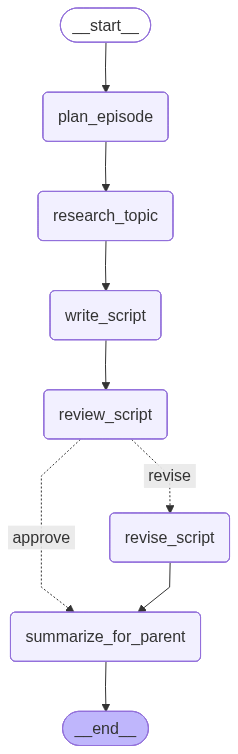

In [5]:
graph_builder = StateGraph(EpisodeState)

graph_builder.add_node("plan_episode", plan_episode)
graph_builder.add_node("research_topic", research_topic)
graph_builder.add_node("write_script", write_script)
graph_builder.add_node("review_script", review_script)
graph_builder.add_node("revise_script", revise_script)
graph_builder.add_node("summarize_for_parent", summarize_for_parent)

graph_builder.add_edge(START, "plan_episode")
graph_builder.add_edge("plan_episode", "research_topic")
graph_builder.add_edge("research_topic", "write_script")
graph_builder.add_edge("write_script", "review_script")
graph_builder.add_conditional_edges(
    "review_script",
    route_after_review,
    {
        "approve": "summarize_for_parent",
        "revise": "revise_script",
    },
)
graph_builder.add_edge("revise_script", "summarize_for_parent")
graph_builder.add_edge("summarize_for_parent", END)

graph = graph_builder.compile()
graph


In [6]:
approved_result = graph.invoke(
    {
        "age_group": "6-8",
        "topic": "the moon",
        "duration_minutes": 3,
        "tone": "playful",
        "review_status": "approve",
    }
)

approved_result


{'age_group': '6-8',
 'topic': 'the moon',
 'duration_minutes': 3,
 'tone': 'playful',
 'review_status': 'approve',
 'plan': '- Audience: 6-8\n- Topic: the moon\n- Length: about 3 minutes\n- Tone: playful\n- Characters: Curious Kid Leo, Dr. Spark\n- Goal: teach one science idea with easy English and repetition',
 'science_fact': 'The moon does not make its own light. It reflects light from the sun, and it moves around Earth.',
 'target_words': ['moon', 'light', 'night'],
 'parent_tip': 'Ask the child to repeat the key phrase and explain one idea in their own words.',
 'script': "[Leo] Dr. Spark, I want to learn about the moon!\n\n[Dr. Spark] Great question, Leo. Here is a simple idea: The moon does not make its own light. It reflects light from the sun, and it moves around Earth.\n\n[Leo] Wow! Can you say it again?\n\n[Dr. Spark] Sure. Learning about the moon is fun. Look up! Ask why! Science is fun!\n\n[Leo] Look up! Ask why! Science is fun!\n\n[Dr. Spark] Today's words are: moon, lig

In [7]:
revised_result = graph.invoke(
    {
        "age_group": "6-8",
        "topic": "rainbows",
        "duration_minutes": 3,
        "tone": "gentle",
        "review_status": "revise",
        "revision_request": "Use shorter sentences and more repetition.",
    }
)

revised_result


{'age_group': '6-8',
 'topic': 'rainbows',
 'duration_minutes': 3,
 'tone': 'gentle',
 'review_status': 'approve',
 'revision_request': 'Use shorter sentences and more repetition.',
 'plan': '- Audience: 6-8\n- Topic: rainbows\n- Length: about 3 minutes\n- Tone: gentle\n- Characters: Curious Kid Leo, Dr. Spark\n- Goal: teach one science idea with easy English and repetition',
 'science_fact': 'A rainbow appears when sunlight passes through tiny drops of water and the light spreads into many colors.',
 'target_words': ['rainbow', 'color', 'rain'],
 'parent_tip': 'Ask the child to repeat the key phrase and explain one idea in their own words.',
 'script': "[Leo] Dr. Spark, I want to learn about rainbows!\n\n[Dr. Spark] Great question, Leo. Here is a simple idea: A rainbow appears when sunlight passes through tiny drops of water and the light spreads into many colors.\n\n[Leo] Wow! Can you say it again?\n\n[Dr. Spark] Sure. Learning about rainbows is fun. Look up! Ask why! Science is fun!